# Assignment 1: Epidemiological Models
# Group 5

## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

## 2. Part 1: Parameter Analysis Function

In this section we investigated how different recovery rates(betas) affect the dynamics of the SIRD model. 
The transmission rate, mortality rate, total population, initial number of infected individuals, 
and simulation duration are kept constant, while the recovery rate γ is varied from 0.05 to 0.25.

For each recovery rate, the model calculates the basic reproduction number, peak number of infectious individuals,
the day of the infection peak, and the total number of deaths at the end of the simulation.

In [4]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters
    ----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns
    -------
    pandas.DataFrame
        Results summary for each recovery rate
    """

    # Recovery rates required in the assignment
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]

    # List where summary results will be stored
    results = []

    # Initial conditions
    S0 = N - I0
    R0_initial = 0
    D0 = 0
    y0 = [S0, I0, R0_initial, D0]

    # Time points
    t = np.linspace(0, simulation_days - 1, simulation_days)

    # Create figure for infectious epidemic curves
    plt.figure(figsize=(10, 6))

    # Run the SIRD model for each recovery rate
    for gamma in gamma_values:

        sol = odeint(
            sird_model,
            y0,
            t,
            args=(beta, gamma, mu)
        )

        S, I, R, D = sol.T

        # Calculate required epidemic measures
        R0 = beta / gamma
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        total_deaths = D[-1]

        # Save results
        results.append([
            gamma,
            R0,
            peak_infected,
            peak_day,
            total_deaths
        ])

        # Plot infectious curve for this recovery rate
        plt.plot(
            t,
            I,
            linewidth=2,
            label=f'γ = {gamma:.2f}, R₀ = {R0:.1f}'
        )

    # Format epidemic plot
    plt.xlabel('Time (days)')
    plt.ylabel('Number of Infectious Individuals')
    plt.title('Effect of Recovery Rate on SIRD Epidemic Dynamics')
    plt.legend(title='Recovery rate')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Create results DataFrame
    results_df = pd.DataFrame(
        results,
        columns=[
            'gamma',
            'R0',
            'peak_infected',
            'peak_day',
            'total_deaths'
        ]
    )

    return results_df

## The SIRD model from computer assignment

In [8]:
# 🟡 adapt the differential equations for the extended model
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    TODO: Adapt the SIR model to include deaths

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y  # Note: now 4 compartments
    N = S + I + R + D

    # TODO: Modify the SIR equations to include death
    # Hint: Infectious people can either recover (rate γ) OR die (rate μ)

    dSdt = -beta * S * I / N
    dIdt = (beta * S * I / N) - ((gamma + mu) * I)
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


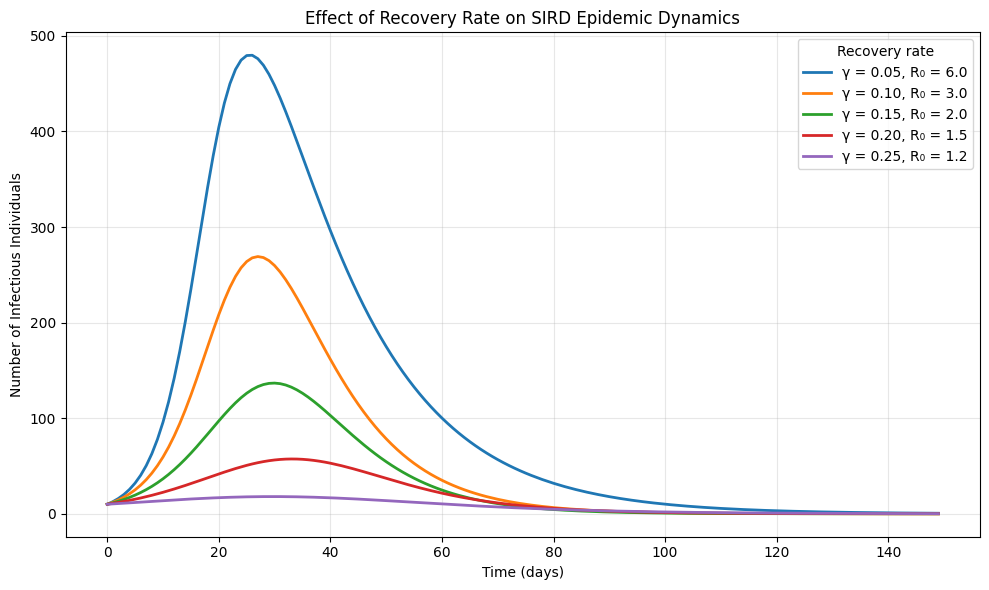

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,479.737984,26,165.413925
1,0.10,3.0,269.138176,27,83.572705
2,0.15,2.0,136.756407,30,47.712503
3,0.20,1.5,57.359889,33,26.019199
4,0.25,1.2,18.021355,30,11.436114


In [7]:
results_df = analyze_recovery_rates(
    beta=0.3,
    mu=0.01,
    N=1000,
    I0=10,
    simulation_days=150
)

results_df

## 3. Part 2: Scenario Comparison

We compare the required high- and low-transmission scenarios. Each scenario uses the same five recovery rates from Part 1 so that the influence of transmission and mortality rates can be assessed directly.

In [ ]:
# Required scenario parameters
scenario_a = {'beta': 0.4, 'mu': 0.02, 'N': 1000, 'I0': 5, 'simulation_days': 200}
scenario_b = {'beta': 0.2, 'mu': 0.005, 'N': 1000, 'I0': 5, 'simulation_days': 200}

print('Scenario A — High Transmission')
scenario_a_results = analyze_recovery_rates(**scenario_a)
display(scenario_a_results.round(2))

print('Scenario B — Low Transmission')
scenario_b_results = analyze_recovery_rates(**scenario_b)
display(scenario_b_results.round(2))

### Comparative visualization

The panels below use identical axes, making differences in epidemic timing and peak size directly comparable.

In [ ]:
# Compare both scenarios using the same time and population scales.
plt.figure(figsize=(14, 5))

for panel, scenario, name in [(1, scenario_a, 'Scenario A: High Transmission'),
                              (2, scenario_b, 'Scenario B: Low Transmission')]:
    plt.subplot(1, 2, panel)
    y0 = [scenario['N'] - scenario['I0'], scenario['I0'], 0, 0]
    t = np.linspace(0, scenario['simulation_days'] - 1, scenario['simulation_days'])

    for gamma in [0.05, 0.1, 0.15, 0.2, 0.25]:
        sol = odeint(sird_model, y0, t,
                     args=(scenario['beta'], gamma, scenario['mu']))
        plt.plot(t, sol[:, 1], linewidth=2, label=f'γ = {gamma:.2f}')

    plt.title(name)
    plt.xlabel('Time (days)')
    plt.ylabel('Infectious individuals')
    plt.xlim(0, 199)
    plt.ylim(0, 600)
    plt.legend(title='Recovery rate')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Public health interpretation

Scenario A is worse for public health for all five recovery rates we tested. The disease spreads faster and the death rate is higher. This leads to more people being infectious at the same time and more deaths by the end of the simulation.

For example when the recovery rate is 0.10 the number of infectious people in Scenario A reaches about 340 on day 22. In Scenario B it reaches about 139 on day 52. Scenario A also ends with about 160 deaths compared with about 37 in Scenario B. Having more people infectious at once could put more pressure on hospitals. The earlier peak also leaves less time to prepare.

Scenario A peaks earlier at the three lowest recovery rates. But in Scenario B at recovery rates of 0.20 and 0.25 infections fall from the start. This is why its peak day is 0 in those rows.

Even at a recovery rate of 0.25 Scenario A still reaches about 63 infectious people and ends with about 43 deaths. In Scenario B infections stay at or below the initial five cases. The model gives about 0.43 deaths which is a model estimate rather than a literal part of a person. Overall Scenario B has much better results and shows why slowing the spread and helping people recover matters.